In [2]:
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, BaseMessage
from langchain_core.prompts import ChatPromptTemplate
from langgraph.checkpoint.memory import MemorySaver
from typing import Annotated, List, Optional, TypedDict, Union, Dict
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, END, START
import os
import uuid
import json
import random
import sqlite3
from pydantic import BaseModel, Field

with open('../database/map.json', 'r') as f:
    map_data = json.load(f)['data']

e:\bilal\Projects\livekit-voice-agent\agent\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
api_key = "api_key"
llm = ChatGroq(
    api_key=api_key,
    model="llama-3.3-70b-versatile",
    temperature=0,
)

In [340]:
import operator


class QuestionRecord(TypedDict):
    id: str
    question: str
    user_answer: Optional[str]
    # score: int
    # feedback: Dict[str, str]


# --- STATE MANAGEMENT ---
class InterviewState(TypedDict):
    """
    Maintains the state of the interview, including history and progress.
    """
    messages: Annotated[List[BaseMessage], operator.add]
    category: str | None
    skill: str
    max_questions: int
    # questions_asked is the single source of truth for question tracking.
    # Use len(questions_asked) instead of a separate question_count.
    questions_asked: List[QuestionRecord]
    # Flags to control flow
    is_off_topic: bool
    is_complete: bool

In [341]:
def pre_interview_node(state: InterviewState):
    print('Interview Started')
    category = input('Please tell me which job_role you want to be interviewed on ? ')
    skill = input('Which skill? ')

    return {
        "skill": skill,
        "category": category
    }

In [342]:
def greeting_node(state: InterviewState):
    """
    Requirement 2: Greet and set context.
    """
    category = state["category"]
    skill = state["skill"]

    greeting = (
        f"Hello! I am your AI Interviewer. Today we will be conducting an interview "
        f"focused on **{category}** specifically regarding **{skill}** skills. "
        f"Let's begin."
    )
    return {"messages": [AIMessage(content=greeting)]}

In [343]:
def retrieve_question_id(state: InterviewState) -> Optional[str]:
    """
    Fetch a random, un-asked question ID from map.json.
    Returns None if category/skill not found or all questions exhausted.
    """
    category = state.get("category")
    skill = state.get("skill")
    difficulty = "easy"

    if category not in map_data or skill not in map_data[category]:
        return None

    questions = map_data[category][skill].get(difficulty, [])
    if not questions:
        return None

    # Extract asked IDs as a set (O(1) lookup) — Fix #14
    asked_ids = {q["id"] for q in state.get("questions_asked", [])}

    # Filter remaining
    available = [q_id for q_id in questions if q_id not in asked_ids]

    if not available:
        return None

    return random.choice(available)

In [344]:
DB_PATH = "../database/interviewer.db"


def get_question_from_db(question_id: str) -> Optional[QuestionRecord]:
    """
    Fetch the question row for a given question_id and return as QuestionRecord.
    Returns None if no question with that ID exists.
    """
    query = """
        SELECT *
        FROM questions
        WHERE id = ?
    """

    conn = None
    try:
        conn = sqlite3.connect(DB_PATH)
        conn.row_factory = sqlite3.Row

        cursor = conn.cursor()
        cursor.execute(query, (question_id,))  # Fix #6: trailing comma for tuple
        row = cursor.fetchone()

        if row is None:
            return None

        # Fix #4: valid return syntax
        new_record: QuestionRecord = {
            "id": row["id"],
            "question": row["question"],
            "user_answer": None
        }
        return new_record

    except sqlite3.Error as e:
        print(f"Database error: {e}")
        return None

    finally:
        if conn:
            conn.close()

In [345]:
def generate_question_by_llm(state: InterviewState) -> QuestionRecord:
    """Generate a question using the LLM when no DB question is available."""
    skill = state["skill"]
    category = state["category"]

    prompt = ChatPromptTemplate.from_template(
        "You are technical interviewer of '{category}' in '{skill}'. "
        "Create an easy level interview question in one line"
    )
    chain = prompt | llm
    response = chain.invoke({"category": category, "skill": skill})

    question_id = str(uuid.uuid4())

    # Fix #3: valid variable assignment + return
    new_record: QuestionRecord = {
        "id": question_id,
        "question": response.content,
        "user_answer": None
    }
    return new_record

In [ ]:
def question_generator_node(state: InterviewState):
    """
    Fetch question from DB (via map.json lookup), or fallback to LLM.
    Completion check is handled in router_logic, not here.
    """
    # Fix #11: correct function name
    q_id = retrieve_question_id(state)

    question_content: Optional[QuestionRecord] = None
    if q_id is None:
        question_content = generate_question_by_llm(state)
    else:  # Fix #5: added colon
        question_content = get_question_from_db(q_id)

    # Fallback if DB lookup also fails
    if question_content is None:
        question_content = generate_question_by_llm(state)

    updated_stack = state.get("questions_asked", []) + [question_content]

    return {
        # Fix #9: bracket access on TypedDict, wrap in AIMessage
        "messages": [AIMessage(content=question_content["question"])],
        "questions_asked": updated_stack,
        "is_off_topic": False  # Reset off-topic flag
    }

In [347]:
def record_answer_node(state: InterviewState):
    user_answer = input(f"{state['messages'][-1].content}")

    return {
        "messages": [HumanMessage(content=user_answer)]
    }

In [1]:
class ValidationResult(BaseModel):
    """Whether the candidate's response is off-topic."""
    is_off_topic: bool = Field(
        description="True if the response is off-topic or casual chat, "
                    "False if it's a genuine attempt to answer the question."
    )

def answer_analyzer_node(state: InterviewState):
    """
    Requirement 4: Record answer if valid. Redirect if off-topic.
    """
    last_user_message = state["messages"][-1].content
    stack = state.get("questions_asked", [])

    if not stack:
        return {}  # Safety check

    # 1. Peek at the top of the stack
    last_question_record = stack[-1]

    # 2. Structured validation — guaranteed bool, no string parsing
    structured_llm = llm.with_structured_output(ValidationResult)

    # Validation Chain
    validation_prompt = ChatPromptTemplate.from_messages([
        ("system",
         "You are an interview moderator. Your job is to determine if the "
         "candidate's response is an attempt to answer the question OR if "
         "they are going off-topic/chatting casually."),
        ("user",
         "Current Question: {question}\nCandidate Response: {response}")
        
    ])

    validator_chain = validation_prompt | structured_llm
    # Fix #9: bracket access
    validation_res = validator_chain.invoke({
        "question": last_question_record["question"],
        "response": last_user_message
    })
    is_off_topic = "YES" in validation_res.content.upper()

    if result.is_off_topic:
        redirect_prompt = ChatPromptTemplate.from_template(
            "The candidate said: '{response}'. This is off-topic. "
            "Politely but firmly bring them back to the interview context "
            "without asking a new question."
        )
        redirect_msg = (redirect_prompt | llm).invoke({"response": last_user_message})

        return {
            "messages": [redirect_msg],
            "is_off_topic": True
        }
    else:
        # 3. Valid Answer: Update the top of the stack
        last_question_record["user_answer"] = last_user_message

        # Replace the old top item with the updated one
        updated_stack = stack[:-1] + [last_question_record]

        return {
            "questions_asked": updated_stack,
            "is_off_topic": False
        }

NameError: name 'BaseModel' is not defined

In [349]:
def completion_node(state: InterviewState):
    """
    Requirement 7: End the interview.
    """
    return {
        "messages": [AIMessage(
            content="Thank you. That concludes our interview session. "
                    "We have recorded your responses."
        )],
        "is_complete": True
    }

In [350]:
# Conditional Logic for the Analyzer
def router_logic(state: InterviewState):
    if state.get("is_complete") | len(state.get("questions_asked", [])) >= state.get("max_questions"):
        return "interview_completed"
    
    if state.get("is_off_topic"):
        # If off-topic, we go to END to wait for user input again, 
        # effectively repeating the wait for the SAME question context.
        return "off_topic" 
    
    # If valid answer, go to ask next question
    return "ask_again"


# Logic after asking a question
def question_router(state: InterviewState):
    if state.get("is_complete"):
        return "finalize"
    return "__end__" # Wait for user input
   


In [351]:
workflow = StateGraph(state_schema=InterviewState)

# 1. Add nodes
workflow.add_node("pre_interview_node", pre_interview_node)
workflow.add_node("greet", greeting_node)
workflow.add_node("ask_question", question_generator_node)
workflow.add_node("record_answer", record_answer_node)
workflow.add_node("analyze_answer", answer_analyzer_node)
workflow.add_node("finalize", completion_node)

# 2. Entry point
workflow.add_edge(START, "pre_interview_node")
workflow.add_edge("pre_interview_node", "greet")
workflow.add_edge("greet", "ask_question")
workflow.add_edge("ask_question", "record_answer")
workflow.add_edge("record_answer", "analyze_answer")
workflow.add_edge("finalize", END)

# 3. Conditional edges from analyze_answer
workflow.add_conditional_edges("analyze_answer", router_logic, {
    "interview_completed": "finalize",
    "ask_again": "ask_question",
    "off_topic": "record_answer"
})

# 4. Compile
checkpointer = MemorySaver()
app = workflow.compile(checkpointer=checkpointer)

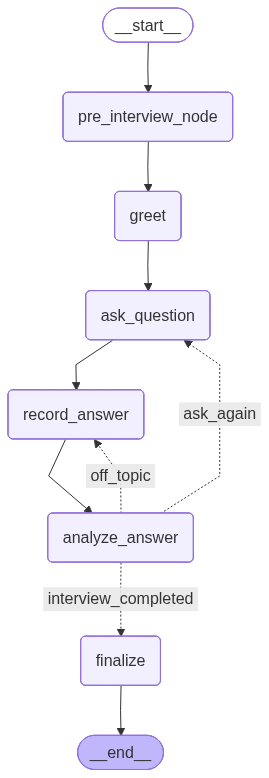

In [352]:
# In a Jupyter notebook (strongly recommended)
from IPython.display import Image, display

# Option A: Nice-looking Mermaid diagram (PNG)
display(Image(app.get_graph().draw_mermaid_png()))

# Option B: Just print the Mermaid code (good for Markdown, GitHub, docs)
# print(app.get_graph().draw_mermaid())

In [353]:
config = {"configurable": {"thread_id": "interview_session_001"}}

# Fix #18: removed question_count and interview_record, added questions_asked
initial_state = {
    "max_questions": 2,
    "questions_asked": [],
    "messages": [],
    "is_off_topic": False,
    "is_complete": False
}

print("--- Starting Interview ---")
app.invoke(initial_state, config=config)

--- Starting Interview ---
Interview Started


{'messages': [AIMessage(content="Hello! I am your AI Interviewer. Today we will be conducting an interview focused on **Frontend** specifically regarding **React** skills. Let's begin.", additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
  AIMessage(content='What is the difference between the "state" and "props" in a React component, and when would you use each?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='props are the properties that parent component can pass to child, and state the variable that store some values and in case of useState, it renders UI on change', additional_kwargs={}, response_metadata={}),
  AIMessage(content='What is the difference between the "controlled" and "uncontrolled" components in React, and when would you use each?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content="let's go to gym", additional_kwargs={},